In [9]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

In [10]:
df = pd.read_csv('cleaned_deceptive-opinion.csv')
df.head()

,deceptive,hotel,polarity,source,text
0,truthful,conrad,positive,TripAdvisor,stayed one night getaway family thursday. trip...
1,truthful,hyatt,positive,TripAdvisor,triple rate upgrade view room less $200 also i...
2,truthful,hyatt,positive,TripAdvisor,comes little late finally catching reviews pas...
3,truthful,omni,positive,TripAdvisor,omni chicago really delivers fronts spaciousne...
4,truthful,hyatt,positive,TripAdvisor,asked high floor away elevator got. room pleas...


In [11]:
df['label'] = (df['deceptive'] == 'deceptive').astype(int)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(df['text'], df['label'], test_size=0.2, random_state=42, stratify=df['label'])

In [13]:
tfidf = joblib.load('tfidf_vectorizer.pkl')
X_train_tfidf = tfidf.transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)


In [14]:
nb_model = MultinomialNB(alpha=1.0)
nb_model.fit(X_train_tfidf, y_train)
nb_pred = nb_model.predict(X_test_tfidf)

In [ ]:
nb_acc  = accuracy_score(y_test, nb_pred)
nb_prec = precision_score(y_test, nb_pred)
nb_rec  = recall_score(y_test, nb_pred)
nb_f1   = f1_score(y_test, nb_pred)
nb_cv   = cross_val_score(nb_model, X_train_tfidf, y_train, cv=5, scoring='accuracy').mean()
print(f"  Accuracy : {nb_acc:.4f}")
print(f"  Precision: {nb_prec:.4f}")
print(f"  Recall   : {nb_rec:.4f}")
print(f"  F1-Score : {nb_f1:.4f}")
print(f"  CV Acc (5-fold): {nb_cv:.4f}")
print("\nClassification Report:\n", classification_report(y_test, nb_pred, target_names=['Truthful', 'Deceptive']))
print("\nConfusion Matrix:\n", cm)

  Accuracy : 0.8781
  Precision: 0.8380
  Recall   : 0.9375
  F1-Score : 0.8850
  CV Acc (5-fold): 0.8852

Classification Report:
               precision    recall  f1-score   support

    Truthful       0.93      0.82      0.87       160
   Deceptive       0.84      0.94      0.88       160

    accuracy                           0.88       320
   macro avg       0.88      0.88      0.88       320
weighted avg       0.88      0.88      0.88       320



In [16]:
joblib.dump(nb_model, 'nb_model.pkl')

['nb_model.pkl']

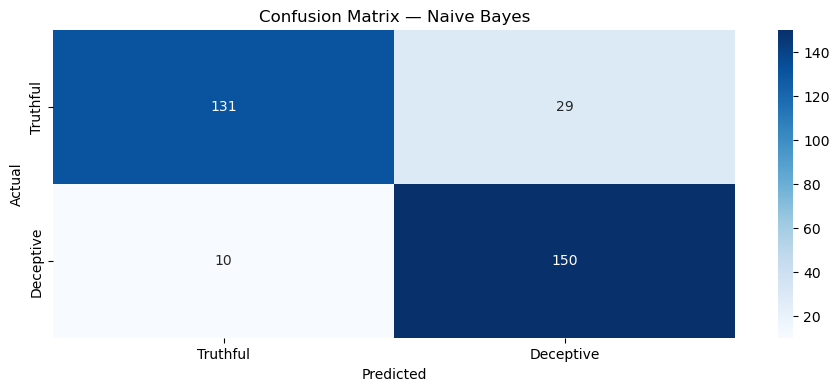

In [17]:
fig, ax = plt.subplots(figsize=(11, 4))
cm = confusion_matrix(y_test, nb_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Truthful', 'Deceptive'],
            yticklabels=['Truthful', 'Deceptive'])
ax.set_title('Confusion Matrix — Naive Bayes')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.show()